# 1. Setup

In [ ]:
# packages
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import shutil
from PIL import Image

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on device {device}")

torch.manual_seed(256)
np.random.seed(256)

Running on device cuda:0


# **All directories are based on google colab's file structure.**

## 2. Data

Clone Repo

In [2]:
! git clone https://github.com/jfung07/UCLA_Thesis

Cloning into 'UCLA_Thesis'...
remote: Enumerating objects: 1719, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1719 (delta 0), reused 7 (delta 0), pack-reused 1711 (from 1)
Receiving objects: 100% (1719/1719), 928.00 MiB | 18.41 MiB/s, done.
Updating files: 100% (1683/1683), done.


## 2a. CSV

In [3]:
base = "/content/UCLA_Thesis/data"
df = pd.read_excel("UCLA_Thesis/data/setters.xlsx")

### 2a1. Response Variable

Attack Success

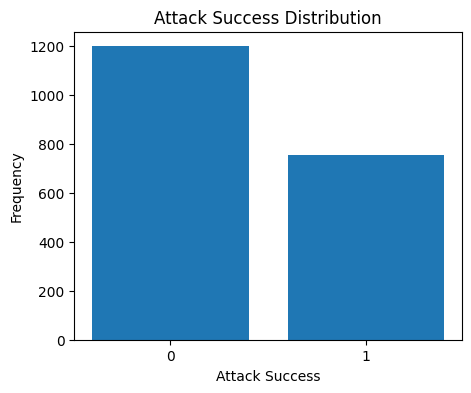

In [4]:
nums = df['kill'].value_counts()
fig, ax = plt.subplots(figsize = (5,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Attack Success")
ax.set_ylabel("Frequency")
ax.set_title("Attack Success Distribution")
plt.show()

2a2. Create kill_data directory

In [5]:
res_data_path = os.path.join(base, "res_data")
os.makedirs(os.path.join(res_data_path), exist_ok=True)
src = os.path.join(base, "setters.xlsx")
dst = os.path.join(res_data_path, "setters.xlsx")
os.makedirs(os.path.dirname(dst), exist_ok = True)
shutil.copy(src, dst)
res_df = loc_df = pd.read_excel(os.path.join(res_data_path, "setters.xlsx"))

## 2b. Images

### 2b1. Label Images

In [6]:
labeled_path = os.path.join(base, "res_data", "labeled_res_images") # /content/UCLA_Thesis/data/res_data/labeled_set_images
os.makedirs(labeled_path, exist_ok=True)
num_images = 0
for game_set in os.listdir(os.path.join(base, "set_images")):
  game_set_path = os.path.join(base, "set_images", game_set) # EX: /content/UCLA_Thesis/data/game_set/game2_set1
  for pos_image in os.listdir(game_set_path): # loops through images within a gameset
    if not pos_image.lower().endswith(".png"):
      continue
    csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
    label = str(res_df['kill'][csv_index])
    class_folder = os.path.join(labeled_path, game_set, label)
    os.makedirs(class_folder, exist_ok=True)
    shutil.copy(os.path.join(game_set_path, pos_image), os.path.join(labeled_path, game_set, class_folder, pos_image)) # from original to labeled path
    num_images += 1

print(f"labeled {num_images} images")

labeled 1677 images


###2b2. Split

In [7]:
# folders
splits = ["train", "val", "test"]
split_images_path = os.path.join(base, "res_data", "setRes_split") # /content/UCLA_Thesis/data/res_data/setRes_split
os.makedirs(split_images_path, exist_ok=True)
for game_set in os.listdir(labeled_path): # labeled path = /content/UCLA_Thesis/data/labeled_set_images
  game_set_splits_path = os.path.join(split_images_path, game_set) # EX. /content/UCLA_Thesis/data/setRes_split/game2_set1
  for s in splits:
    os.makedirs(os.path.join(game_set_splits_path, s), exist_ok=True)

In [8]:
np.random.seed(256)
# populate
for game_set in os.listdir(labeled_path): # labeled path = /content/UCLA_Thesis/data/res_data/labeled_set_images
  game_set_path = os.path.join(labeled_path, game_set) # EX. /content/UCLA_Thesis/data/res_data/labeled_set_images/game2_set1
  for res in os.listdir(game_set_path):
    res_path = os.path.join(game_set_path, res) # EX. /content/UCLA_Thesis/data/res_data/labeled_set_images/game2_set1/1
    imgs = [f for f in os.listdir(res_path) if f.lower().endswith(".png")]
    random.shuffle(imgs)
    n = len(imgs)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    train_imgs, val_imgs, test_imgs = imgs[:train_end], imgs[train_end:val_end], imgs[val_end:]
    # res within split
    for s in splits:
      # make folders
      os.makedirs(os.path.join(split_images_path, game_set, s, res), exist_ok = True)
    for subset, subset_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
      outdir = os.path.join(split_images_path, game_set, subset, res)

      for file in subset_imgs:
        shutil.copy(os.path.join(res_path, file), os.path.join(outdir, file))

#### CSV Lines based on Split

Train

In [9]:
res_train_df = pd.DataFrame()
# loop through game sets in split
split_images_path = os.path.join(base, "res_data", "setRes_split")
for game_set in os.listdir(split_images_path):
  # go through train of each game
  train_path = os.path.join(split_images_path, game_set, "train")
  # loop through results
  for res in os.listdir(train_path):
    res_path = os.path.join(train_path, res)
    for pos_image in os.listdir(res_path):
      csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
      row = df.loc[csv_index]
      res_train_df = pd.concat([res_train_df, row.to_frame().T], ignore_index=True)

out_path = "/content/UCLA_Thesis/data/res_data/train.xlsx"
os.makedirs(os.path.dirname(out_path), exist_ok = True)
res_train_df.to_excel(out_path, index = False)

In [10]:
print(len(res_train_df))
res_train_df.head(5)

1152


,observation,points1,points2,team1_diff,team2_diff,tot_point,set,game,rotation,receiver_loc,pass_loc,pass_quality,set_loc,num_block,set_receiver,kill,team,level,game_sex
0,1880,16,12,4,-4,28,3,8,6,6,2,4,2,1,middle1,1,france,Pro,M
1,1861,5,4,1,-1,9,3,8,5,1,7,5,4,1,outside1,1,france,Pro,M
2,1862,6,4,2,-2,10,3,8,3,5,3,4,5,2,opposite1,1,japanM,Pro,M
3,1879,15,11,4,-4,26,3,8,5,6,3,4,3,1,middle2,1,france,Pro,M
4,1899,22,17,5,-5,39,3,8,2,1,7,5,1,1,middle1,1,japanM,Pro,M


Validation

In [10]:
res_val_df = pd.DataFrame()
# loop through game sets in split
split_images_path = os.path.join(base, "res_data", "setRes_split")
for game_set in os.listdir(split_images_path):
  # go through val of each game
  val_path = os.path.join(split_images_path, game_set, "val")
  # loop through results
  for res in os.listdir(val_path):
    res_path = os.path.join(val_path, res)
    for pos_image in os.listdir(res_path):
      csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
      row = df.loc[csv_index]
      res_val_df = pd.concat([res_val_df, row.to_frame().T], ignore_index=True)

out_path = "/content/UCLA_Thesis/data/res_data/val.xlsx"
os.makedirs(os.path.dirname(out_path), exist_ok = True)
res_val_df.to_excel(out_path, index = False)

In [12]:
print(len(res_val_df))
res_val_df.head(5)

251


,observation,points1,points2,team1_diff,team2_diff,tot_point,set,game,rotation,receiver_loc,pass_loc,pass_quality,set_loc,num_block,set_receiver,kill,team,level,game_sex
0,1898,21,17,4,-4,38,3,8,4,5,7,5,D,1,opposite1,1,france,Pro,M
1,1872,10,8,2,-2,18,3,8,6,6,3,3,4,2,outside3,1,japanM,Pro,M
2,1882,18,13,5,-5,31,3,8,5,5,7,5,1,2,middle2,1,japanM,Pro,M
3,1881,17,13,4,-4,30,3,8,1,2,3,4,1,1,middle1,1,france,Pro,M
4,1890,19,15,4,-4,34,3,8,3,1,7,5,1,2,middle2,0,france,Pro,M


Test

In [11]:
res_test_df = pd.DataFrame()
# loop through game sets in split
split_images_path = os.path.join(base, "res_data", "setRes_split")
for game_set in os.listdir(split_images_path):
  # go through test of each game
  test_path = os.path.join(split_images_path, game_set, "test")
  # loop through results
  for res in os.listdir(test_path):
    res_path = os.path.join(test_path, res)
    for pos_image in os.listdir(res_path):
      csv_index = int(pos_image.replace("set", "").replace(".png", "").strip()) - 1
      row = df.loc[csv_index]
      res_test_df = pd.concat([res_test_df, row.to_frame().T], ignore_index=True)

out_path = "/content/UCLA_Thesis/data/res_data/test.xlsx"
os.makedirs(os.path.dirname(out_path), exist_ok = True)
res_test_df.to_excel(out_path, index = False)

In [14]:
print(len(res_test_df))
res_test_df.head(5)

274


,observation,points1,points2,team1_diff,team2_diff,tot_point,set,game,rotation,receiver_loc,pass_loc,pass_quality,set_loc,num_block,set_receiver,kill,team,level,game_sex
0,1868,8,8,0,0,16,3,8,2,2,7,5,1,1,middle1,1,france,Pro,M
1,1854,0,1,-1,1,1,3,8,2,3,7,3,back1,1,middle1,1,france,Pro,M
2,1860,3,2,1,-1,5,3,8,3,5,3,4,2,1,middle2,1,france,Pro,M
3,1875,13,10,3,-3,23,3,8,4,4,3,4,dump,0,setter1,1,france,Pro,M
4,1871,9,8,1,-1,17,3,8,6,5,4,2,D,3,opposite1,0,japanM,Pro,M


Delete labeled_set_images

In [12]:
shutil.rmtree(labeled_path)

### 2b3. Combined Split

Train

In [13]:
split_comb_path = os.path.join(base, "res_data", "split_comb") # /content/UCLA_Thesis/data/res_data/split_comb
os.makedirs(os.path.dirname(split_comb_path), exist_ok=True)
train_comb_path = os.path.join(split_comb_path, "train_comb") # /content/UCLA_Thesis/data/res_data/split_comb/train_comb
os.makedirs(os.path.dirname(train_comb_path), exist_ok=True)
# loop through game sets
for game_set in os.listdir(split_images_path):
  # collect all train images across game sets
  game_set_train = os.path.join(base, "res_data", "setRes_split", game_set, "train") # /content/UCLA_Thesis/data/res_data/setRes_split/game2_set1/train
  for res in os.listdir(game_set_train):
    res_comb_path = os.path.join(train_comb_path, res)
    os.makedirs(res_comb_path, exist_ok=True)
    res_path = os.path.join(game_set_train, res)
    for pos_img in os.listdir(res_path):
      src = os.path.join(res_path, pos_img)
      dst = os.path.join(res_comb_path, pos_img)
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      shutil.copy(src, dst)

Validation

In [14]:
val_comb_path = os.path.join(split_comb_path, "val_comb") # /content/UCLA_Thesis/data/res_data/split_comb/val_comb
os.makedirs(os.path.dirname(val_comb_path), exist_ok=True)
# loop through game sets
for game_set in os.listdir(split_images_path):
  # collect all validation images across game sets
  game_set_val = os.path.join(base, "res_data", "setRes_split", game_set, "val") # /content/UCLA_Thesis/data/loc_data/setLoc_split/game2_set1/val
  for res in os.listdir(game_set_val):
    res_comb_path = os.path.join(val_comb_path, res)
    os.makedirs(res_comb_path, exist_ok=True)
    res_path = os.path.join(game_set_val, res)
    for pos_img in os.listdir(res_path):
      src = os.path.join(res_path, pos_img)
      dst = os.path.join(res_comb_path, pos_img)
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      shutil.copy(src, dst)

Test

In [15]:
test_comb_path = os.path.join(split_comb_path, "test_comb") # /content/UCLA_Thesis/data/res_data/split_comb/test_comb
os.makedirs(os.path.dirname(test_comb_path), exist_ok=True)
# loop through game sets
for game_set in os.listdir(split_images_path):
  # collect all testing images across game sets
  game_set_test = os.path.join(base, "res_data", "setRes_split", game_set, "test") # /content/UCLA_Thesis/data/res_data/setRes_split/game2_set1/test
  for res in os.listdir(game_set_test):
    res_comb_path = os.path.join(test_comb_path, res)
    os.makedirs(res_comb_path, exist_ok=True)
    res_path = os.path.join(game_set_test, res)
    for pos_img in os.listdir(res_path):
      src = os.path.join(res_path, pos_img)
      dst = os.path.join(res_comb_path, pos_img)
      os.makedirs(os.path.dirname(dst), exist_ok=True)
      shutil.copy(src, dst)

### 2b3. Transform Images

Get data mean and standard deviation for normalizing.  For this project, I am not analyzing within game, so I use the combination of all game set training sets, and same for the validation and test sets.  However, I split the data such that other research can analyze data within games.

In [19]:
means = []
stdevs = []
for res in os.listdir(train_comb_path):
  for pos in os.listdir(os.path.join(train_comb_path, res)):
    if not pos.lower().endswith((".png")):
      continue
    path = os.path.join(train_comb_path, res, pos)
    img = Image.open(path).convert("RGB")
    arr = np.array(img) / 255.0
    means.append(arr.mean(axis = (0,1)))
    stdevs.append(arr.std(axis = (0,1)))
train_mean = np.mean(means, axis = 0)
train_stdev = np.mean(stdevs, axis = 0)
print(f"Mean: {train_mean} and Stdev: {train_stdev}")

Mean: [0.42255352 0.4005284  0.41412918] and Stdev: [0.34083626 0.27902678 0.25625882]


Transforms

In [20]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 0.5), # keeps ground and ceiling orientation
    # random cropping
    transforms.RandomResizedCrop(
      size = (1024, 512),
      scale = (0.8, 1.0),
      ratio = (1.8, 2.2)
    ),
    # random color
    transforms.ColorJitter(
        brightness = 0.2,
        contrast = 0.2,
        saturation = 0.2,
        hue = 0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean = train_mean, std = train_stdev)
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = train_mean, std = train_stdev)
])

Transform Data

In [21]:
train_ds = datasets.ImageFolder(train_comb_path,
                                transform = train_transform)
val_ds = datasets.ImageFolder(val_comb_path,
                              transform = val_test_transform)
test_ds = datasets.ImageFolder(test_comb_path,
                               transform = val_test_transform)
print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

Training samples: 1152
Validation samples: 251
Test samples: 274


###2b4. Data Loader

Use batch sizes of either 8 or 16 because images are large on a medium size data set.   
Choices:
- 8
  - lr = 0.0001 with adam or
  - lr = 0.01, momentum = 0.9 with sgd
  - scaler = torch.cuda.amp.GradScaler()
  - num_workers = 2(colab)
- 16
  - lr = 0.0001 and weight_decay = 0.0001 with adam or
  - lr = 0.02, momentum = 0.9 with sgd
  - scaler = torch.cuda.amp.GradScaler()
  - num_workers = 4(colab)
  - loss function: nn.BCEWithLogitsLoss() because the data is binary, works well with imbalanced data

Use batch_size = 16 because it gives more information with smoother gradients.  8 might overfit the data.

In [22]:
train_loader16 = DataLoader(train_ds, batch_size = 16, shuffle = True,
                           num_workers = 4, pin_memory = True,
                           persistent_workers=True)
val_loader16 = DataLoader(val_ds, batch_size = 16, shuffle = False,
                           num_workers = 4, pin_memory = True,
                           persistent_workers=True)
test_loader16 = DataLoader(test_ds, batch_size = 16, shuffle = False,
                           num_workers = 4, pin_memory = True,
                           persistent_workers=True)
print("For batch_size = 16:")
print(f"Number of training batches: {len(train_loader16)}")
print(f"Number of validation batches: {len(val_loader16)}")
print(f"Number of test batches: {len(test_loader16)}")

For batch_size = 16:
Number of training batches: 72
Number of validation batches: 16
Number of test batches: 18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Structure

In [23]:
images, labels = next(iter(train_loader16))

print(f"Batch shape: {images.shape}")   # [batch_size, channels, height, width]
print(f"Labels shape: {labels.shape}")  # [batch_size]
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch shape: torch.Size([16, 3, 1024, 512])
Labels shape: torch.Size([16])
Image dtype: torch.float32
Label dtype: torch.int64


# 3. Model

## 3a. Simple Baseline

In [17]:
class SimpleCNN(nn.Module):
  def __init__(self, num_classes = 2):
    super(SimpleCNN, self).__init__()
    # input is 1024x512x3 image

    # Block 1: 1024x512 -> 512x256
    self.block1 = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride = 1, padding = 1), # (32 filters, 3x3(kernel), padding = 1)
        nn.ReLU(inplace = True), #-> ReLU
        nn.MaxPool2d(kernel_size=2), # -> max pool 2x2
    )

    # Block 2: 512x256 -> 256x128
    self.block2 = nn.Sequential(
        nn.Conv2d(32, 64, kernel_size=3, stride = 1, padding = 1),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size = 2),
    )

    # Block 3: 256x128 -> 128x64
    self.block3 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=3, stride = 1, padding = 1),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size=2),
    )

    # Block 4: 128x64 -> 64x32
    self.block4 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2),
    )

    # Flatten Layer 64x32x64 -> 64*32*64
    self.flatten = nn.Flatten()

    # Fully Connected Later: 64*32*64 -> 64
    self.layer1 = nn.Linear(64 * 32 * 64, 64)
    self.activation = nn.ReLU()

    # Output Layer: 64 -> 2
    #self.classifier = nn.Linear(64, 2)
    self.classifier = nn.Linear(64, 1)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.flatten(x)
    x = self.activation(self.layer1(x))
    x = self.classifier(x)
    return x


### Summary

In [18]:
simple_model = SimpleCNN(num_classes=1).to(device)

# Print model architecture
print(simple_model)
print(f"\nTotal parameters: {sum(p.numel() for p in simple_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in simple_model.parameters() if p.requires_grad):,}")

SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=131072, out_features=64, bias=True)
  (activation): R

## 3b. VGG

In [19]:
from torch.nn.modules.batchnorm import BatchNorm2d

class VGG(nn.Module):
  def __init__(self, num_classes = 1):
    super().__init__()

    # Block 1: 1024x512 -> 512x256
    self.block1 = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      BatchNorm2d(32),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 2: 512x256 -> 256x128
    self.block2 = nn.Sequential(
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      BatchNorm2d(64),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 3: 256x128 -> 128x64
    self.block3 = nn.Sequential(
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      BatchNorm2d(128),
      nn.ReLU(inplace = True),
      nn.Conv2d(128, 128, kernel_size=3, padding=1),
      BatchNorm2d(128),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 4: 128x64 -> 64x32
    self.block4 = nn.Sequential(
      nn.Conv2d(128, 256, kernel_size=3, padding=1),
      BatchNorm2d(256),
      nn.ReLU(inplace = True),
      nn.Conv2d(256, 256, kernel_size=3, padding=1),
      BatchNorm2d(256),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    # Block 5: 64x32 -> 32x16
    self.block5 = nn.Sequential(
      nn.Conv2d(256, 512, kernel_size=3, padding=1),
      BatchNorm2d(512),
      nn.ReLU(inplace = True),
      nn.Conv2d(512, 512, kernel_size=3, padding=1),
      BatchNorm2d(512),
      nn.ReLU(inplace = True),
      nn.MaxPool2d(2, 2),
    )

    self.gap = nn.AdaptiveAvgPool2d((1,1))
    self.classifier = nn.Linear(512, 1)

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.block5(x)
    x = self.gap(x)
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

### Summary

In [20]:
vgg_model = VGG(num_classes=1).to(device)

# Print model architecture
print(vgg_model)
print(f"\nTotal parameters: {sum(p.numel() for p in vgg_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in vgg_model.parameters() if p.requires_grad):,}")

VGG(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

# 4. Training and Evaluation Helpers

##4a. Training Helper

In [21]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, scaler):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        labels = labels.float().unsqueeze(1) # for BCE

        # Zero gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        with torch.cuda.amp.autocast():
          outputs = model(images) # shape [batch, 1]
          loss = criterion(outputs, labels)

        # Backward pass
        scaler.scale(loss).backward()

        # Update weights
        scaler.step(optimizer)
        scaler.update()

        # Statistics
        running_loss += loss.item() * images.size(0)
        #_, preds = torch.max(outputs, 1)
        preds = (outputs > 0).long()
        running_correct += (preds == labels.long()).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * running_correct / total
    return epoch_loss, epoch_acc

## 4b. Evaluation Helpers

In [22]:
def evaluate(model, val_loader, criterion, device):
    """Evaluate the model on test set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            labels = labels.float().unsqueeze(1) #for bce

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            #_, predicted = outputs.max(1)
            preds = (outputs > 0).long()
            total += labels.size(0)
            #correct += predicted.eq(labels).sum().item()
            correct += (preds == labels.long()).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [23]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
def plot_confusion_matrix(model, test_loader, devce, classes):
  model.eval()
  y_pred = []
  y_true = []

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      #_, predicted = outputs.max(1)
      predicted = (outputs > 0).long()


      #y_pred.extend(predicted.cpu().numpy())
      #y_true.extend(labels.cpu().numpy())
      y_pred.extend(predicted.cpu().numpy().flatten())
      y_true.extend(labels.cpu().numpy().flatten())

  cm = confusion_matrix(y_true, y_pred)
  return cm

#5. Run Basic CNN

Configuration

In [31]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(simple_model.parameters(), lr=LEARNING_RATE, weight_decay = 0.0001)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr = 0.0000001
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_488/2767706237.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


##5a. Train

In [32]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Validation Loss':<12} {'Validation Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(simple_model, train_loader16, criterion, optimizer, device, scaler)

    # Evaluate
    val_loss, val_acc = evaluate(simple_model, val_loader16, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f}")

print("\nTraining complete!")

Starting training...
Epoch    Train Loss   Train Acc    Validation Loss Validation Acc
------------------------------------------------------------


/tmp/ipykernel_488/2045163125.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1        0.6764       58.59        0.6811       60.96       
2        0.6721       60.33        0.6789       60.96       
3        0.6687       60.50        0.6695       60.96       
4        0.6706       60.33        0.6738       60.96       
5        0.6677       61.02        0.6774       60.96       
6        0.6650       60.50        0.6762       54.58       
7        0.6628       61.37        0.6721       60.56       
8        0.6592       61.20        0.6701       60.96       
9        0.6604       60.94        0.6769       60.56       
10       0.6537       60.16        0.6718       60.96       
11       0.6518       63.11        0.6767       60.56       
12       0.6497       63.11        0.6754       61.75       
13       0.6522       62.41        0.6840       60.96       
14       0.6487       62.24        0.6849       60.96       
15       0.6458       62.76        0.6961       60.56       
16       0.6480       61.98        0.6880       60.96       
17       0.6400       62

## 5b. Accuracy and Loss Plots

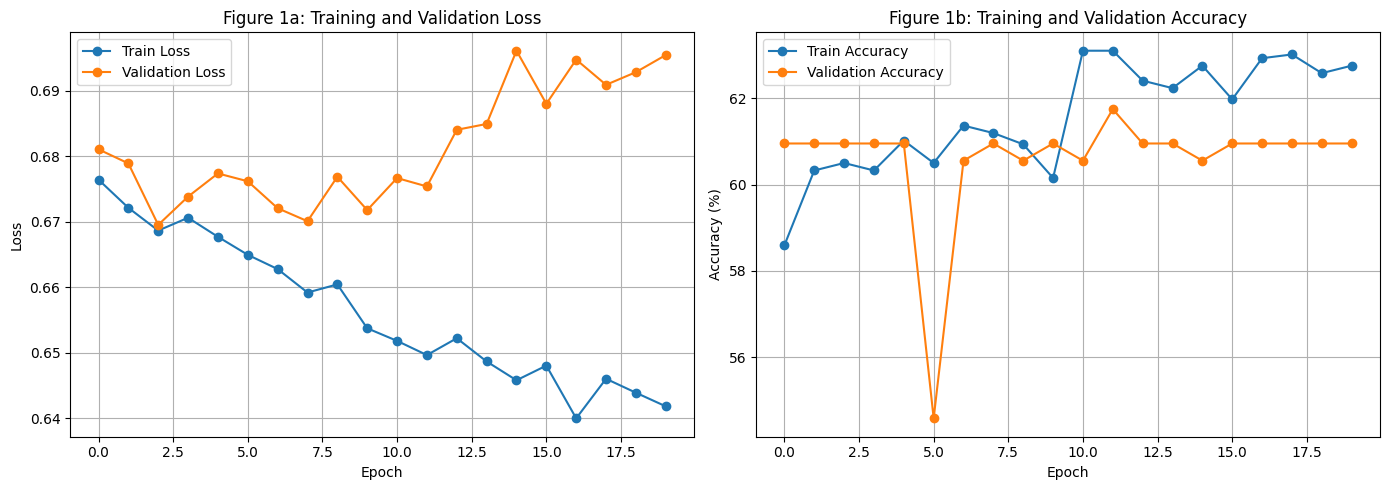

In [33]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Figure 1a: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', marker='o')
axes[1].plot(val_accs, label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Figure 1b: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

##5c. Confusion Matrix

In [34]:
classes = val_loader16.dataset.classes

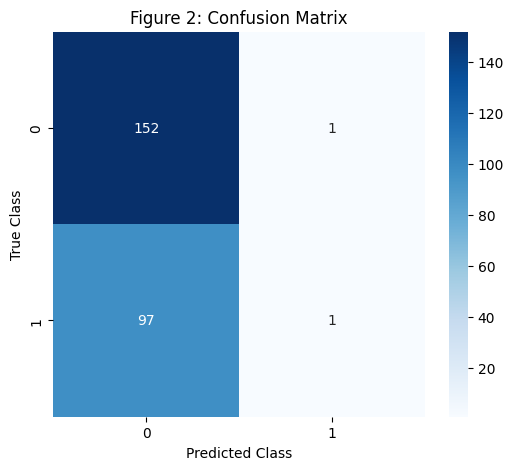

In [35]:
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(simple_model, val_loader16, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 2: Confusion Matrix')
plt.show()

60.96% accuracy, but almost exlusively predicts that the attack is unsuccessful, so look at vgg for hopefully more prediction variation.

# 6. Run VGG

Configuration

In [36]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(vgg_model.parameters(), lr=LEARNING_RATE, weight_decay = 0.0001)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr = 0.0000001
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_488/814883569.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 6a. Train

In [37]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(vgg_model, train_loader16, criterion, optimizer, device, scaler)

    # Evaluate
    val_loss, val_acc = evaluate(vgg_model, val_loader16, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f}")

print("\nTraining complete!")

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
------------------------------------------------------------


/tmp/ipykernel_488/2045163125.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1        0.6847       57.99        0.6893       58.96       
2        0.6735       60.07        0.6649       60.56       
3        0.6729       59.64        0.6742       59.76       
4        0.6725       59.81        0.6662       60.96       
5        0.6703       60.16        0.6679       60.56       
6        0.6707       60.16        0.6664       60.96       
7        0.6690       59.98        0.6658       60.96       
8        0.6687       60.16        0.6616       60.96       
9        0.6695       60.24        0.6643       61.35       
10       0.6680       59.72        0.6632       61.35       
11       0.6672       59.90        0.6633       60.96       
12       0.6690       60.07        0.6616       60.96       
13       0.6646       59.72        0.6617       60.96       
14       0.6667       59.64        0.6630       60.96       
15       0.6646       59.90        0.6618       59.36       
16       0.6651       60.42        0.6601       59.76       
17       0.6657       59

## 6b. Accuracy and Loss Plots

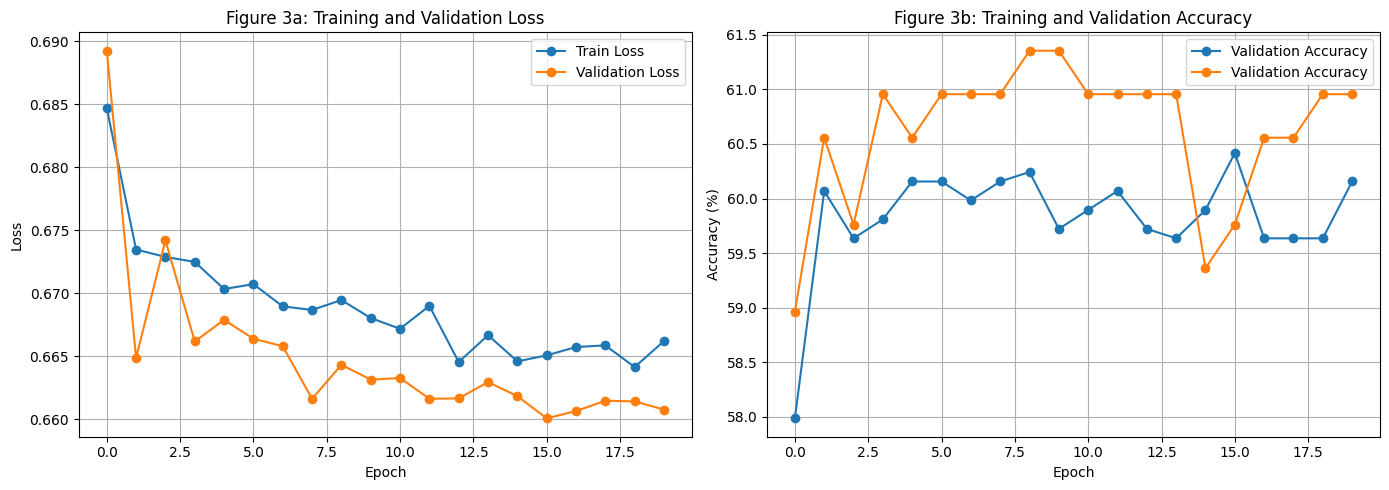

In [38]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Figure 3a: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Validation Accuracy', marker='o')
axes[1].plot(val_accs, label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Figure 3b: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

##6c. Confusion Matrix

In [39]:
classes = val_loader16.dataset.classes

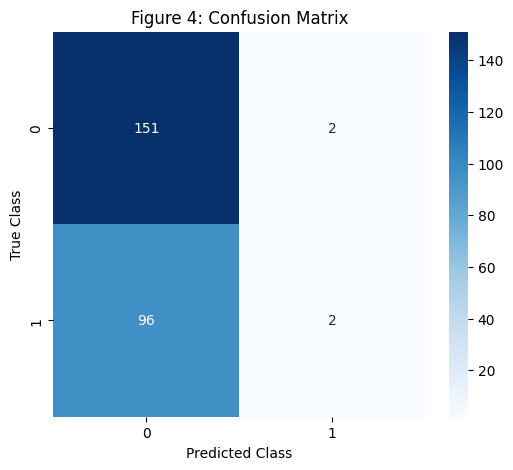

In [40]:
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(vgg_model, val_loader16, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 4: Confusion Matrix')
plt.show()

The VGG model performs the same with a 60.96% accuracy essentially always predicting an unsuccessful attack.  Try balanced data to train model.  

##Unbalanced Vgg on testing

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


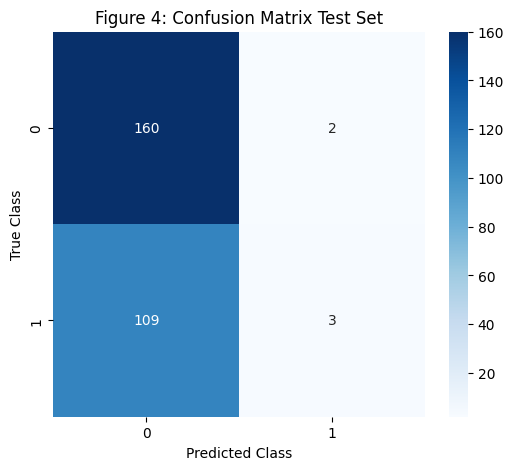

In [41]:
classes = test_loader16.dataset.classes
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(vgg_model, test_loader16, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 4: Confusion Matrix Test Set')
plt.show()

# 7. Balanced training data

## 7a. Data

In [16]:
import os

folder = "/content/UCLA_Thesis/data/res_data/split_comb/train_comb/1"

count1 = sum(
    f.lower().endswith((".png"))
    for f in os.listdir(folder)
)

print("Number of images:", count1)

import os

folder = "/content/UCLA_Thesis/data/res_data/split_comb/train_comb/0"

count0 = sum(
    f.lower().endswith((".png"))
    for f in os.listdir(folder)
)

print("Number of images:", count0)


Number of images: 457
Number of images: 695


###7a1. Select 0

In [24]:
import os
import random
import shutil

src_folder = "/content/UCLA_Thesis/data/res_data/split_comb/train_comb/0"
dst_folder = "/content/UCLA_Thesis/data/res_data/split_comb/train_bal/0"

os.makedirs(dst_folder, exist_ok=True)

# Collect only real PNG files
images = [
    f for f in os.listdir(src_folder)
    if f.lower().endswith(".png") and f.startswith("set")
]

random.seed(256)
selected = random.sample(images, count1)

for img in selected:
    src = os.path.join(src_folder, img)
    dst = os.path.join(dst_folder, img)

    # Copy file directly — DO NOT create a folder
    shutil.copy(src, dst)


###7a2. Copy 1

In [25]:
import os
import shutil

src_folder = "/content/UCLA_Thesis/data/res_data/split_comb/train_comb/1"
dst_folder = "/content/UCLA_Thesis/data/res_data/split_comb/train_bal/1"

os.makedirs(dst_folder, exist_ok=True)

for img in os.listdir(src_folder):
    src = os.path.join(src_folder, img)
    dst = os.path.join(dst_folder, img)

    # Only copy files
    if os.path.isfile(src):
        shutil.copy(src, dst)


## 7b. Transform Images

In [26]:
train_bal_path = os.path.join(split_comb_path, "train_bal")

### 7b1. Means

In [27]:
bal_means = []
bal_stdevs = []
for res in os.listdir(train_bal_path):
  for pos in os.listdir(os.path.join(train_bal_path, res)):
    if not pos.lower().endswith((".png")):
      continue
    path = os.path.join(train_bal_path, res, pos)
    img = Image.open(path).convert("RGB")
    arr = np.array(img) / 255.0
    bal_means.append(arr.mean(axis = (0,1)))
    bal_stdevs.append(arr.std(axis = (0,1)))
train_bal_mean = np.mean(bal_means, axis = 0)
train_bal_stdev = np.mean(bal_stdevs, axis = 0)
print(f"Mean: {train_bal_mean} and Stdev: {train_bal_stdev}")

Mean: [0.42475042 0.40271649 0.41640149] and Stdev: [0.34172687 0.27982338 0.25684307]


###7b2. Transforms

In [28]:
train_bal_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p = 0.5), # keeps ground and ceiling orientation
    # random cropping
    transforms.RandomResizedCrop(
      size = (1024, 512),
      scale = (0.8, 1.0),
      ratio = (1.8, 2.2)
    ),
    # random color
    transforms.ColorJitter(
        brightness = 0.2,
        contrast = 0.2,
        saturation = 0.2,
        hue = 0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean = train_bal_mean, std = train_bal_stdev)
])

val_test_bal_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = train_bal_mean, std = train_bal_stdev)
])

###7b3. Transform Data

In [30]:
train_bal_ds = datasets.ImageFolder(train_bal_path,
                                transform = train_bal_transform)
val_bal_ds = datasets.ImageFolder(val_comb_path,
                              transform = val_test_bal_transform)
test_bal_ds = datasets.ImageFolder(test_comb_path,
                               transform = val_test_bal_transform)
print(f"Training samples: {len(train_bal_ds)}")
print(f"Validation samples: {len(val_bal_ds)}")
print(f"Test samples: {len(test_bal_ds)}")

Training samples: 914
Validation samples: 251
Test samples: 274


Data Loaders

In [31]:
train_bal_loader16 = DataLoader(train_bal_ds, batch_size = 16, shuffle = True,
                           num_workers = 4, pin_memory = True,
                           persistent_workers=True)
val_bal_loader16 = DataLoader(val_bal_ds, batch_size = 16, shuffle = False,
                           num_workers = 4, pin_memory = True,
                           persistent_workers=True)
test_bal_loader16 = DataLoader(test_bal_ds, batch_size = 16, shuffle = False,
                           num_workers = 4, pin_memory = True,
                           persistent_workers=True)
print("For batch_size = 16:")
print(f"Number of training batches: {len(train_bal_loader16)}")
print(f"Number of validation batches: {len(val_bal_loader16)}")
print(f"Number of test batches: {len(test_bal_loader16)}")

For batch_size = 16:
Number of training batches: 58
Number of validation batches: 16
Number of test batches: 18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Structure

In [32]:
images, labels = next(iter(train_bal_loader16))

print(f"Batch shape: {images.shape}")   # [batch_size, channels, height, width]
print(f"Labels shape: {labels.shape}")  # [batch_size]
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels.dtype}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch shape: torch.Size([16, 3, 1024, 512])
Labels shape: torch.Size([16])
Image dtype: torch.float32
Label dtype: torch.int64


Configuration

In [33]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(vgg_model.parameters(), lr=LEARNING_RATE, weight_decay = 0.0001)

# Learning rate scheduler (reduce LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr = 0.0000001
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1600/814883569.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Train

In [34]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(vgg_model, train_bal_loader16, criterion, optimizer, device, scaler)

    # Evaluate
    val_loss, val_acc = evaluate(vgg_model, val_bal_loader16, criterion, device)

    # Update scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f}")

print("\nTraining complete!")

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
------------------------------------------------------------


/tmp/ipykernel_1600/2045163125.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


1        0.7237       49.45        0.6778       60.96       
2        0.6924       52.08        0.7068       54.98       
3        0.6943       52.19        0.6828       56.57       
4        0.6957       51.20        0.6779       61.35       
5        0.6885       53.94        0.6676       60.56       
6        0.6917       51.31        0.6915       54.18       
7        0.6936       50.77        0.6722       62.15       
8        0.6919       52.74        0.6744       60.16       
9        0.6863       53.72        0.6642       61.75       
10       0.6892       52.41        0.6747       60.56       
11       0.6866       54.92        0.6711       59.76       
12       0.6879       55.36        0.6677       60.96       
13       0.6832       55.91        0.6611       61.35       
14       0.6853       54.38        0.6661       59.36       
15       0.6840       55.03        0.6694       59.76       
16       0.6839       54.81        0.6626       59.76       
17       0.6833       56

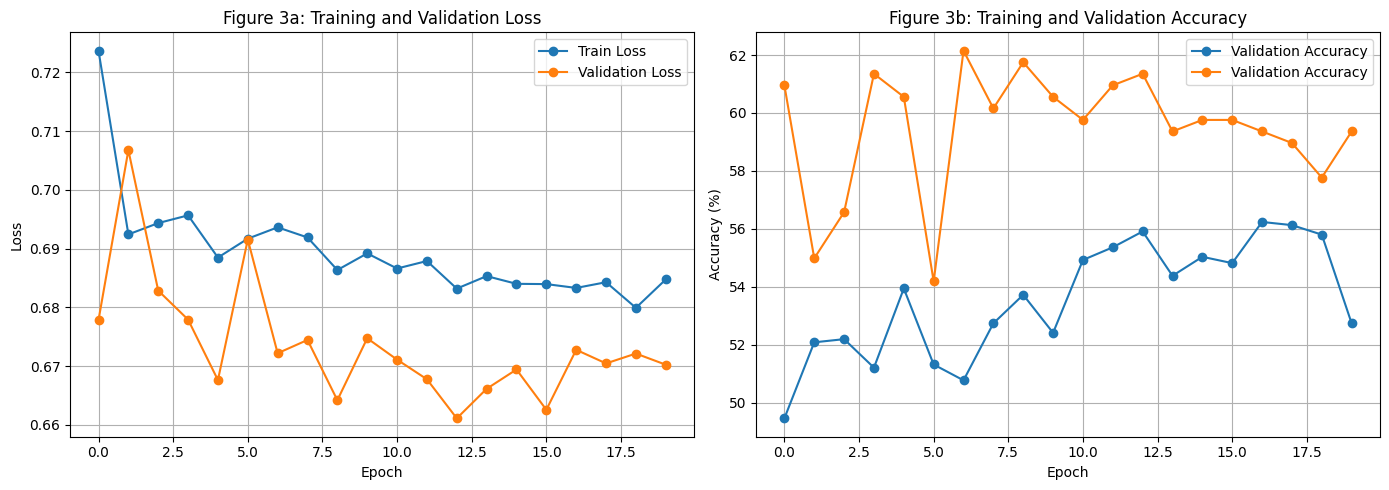

In [35]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Figure 3a: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(train_accs, label='Validation Accuracy', marker='o')
axes[1].plot(val_accs, label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Figure 3b: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

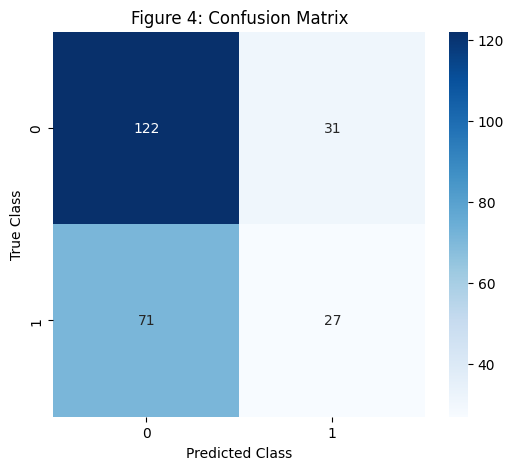

In [39]:
classes = val_bal_loader16.dataset.classes
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(vgg_model, val_bal_loader16, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 4: Confusion Matrix')
plt.show()

More variation but not any better than the unbalanced model.  Observe both vggs on the testing set, but expect the original to have better accuracy by nature of the data.

## Balanced VGG on Testing Set

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


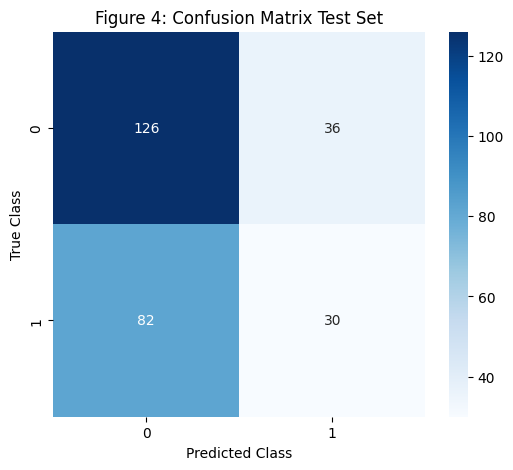

In [38]:
classes = test_bal_loader16.dataset.classes
plt.figure(figsize=(6, 5))
cm = plot_confusion_matrix(vgg_model, test_bal_loader16, device, classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Figure 4: Confusion Matrix Test Set')
plt.show()

In [41]:
(126+30)/len(test_bal_ds)

0.5693430656934306

57% accuracy on test set.  Not great performance considering guessing unsuccessful every time is more accurate, but the predictions vary more as a positive.

In [42]:
df['kill'].value_counts()

,count
kill,
0,1197
1,755


In [43]:
755/(1197+755)

0.3867827868852459

In [44]:
66/len(test_bal_ds)

0.24087591240875914

Slightly more successes in actual data than in prediction.